# Lab - Case Study: Phishing Website Detection bằng Decision Tree và Random Forest

### 1. Bài toán: Phân loại website lừa đảo (Phishing)
Mục tiêu:
- Xây dựng mô hình Decision Tree và Random Forest bằng sklearn.
- Thực hiện quy trình tiền xử lý dữ liệu theo chuẩn báo cáo.
- Đánh giá mô hình bằng Accuracy, Precision, Recall, F1-score và Confusion Matrix.
- Khảo sát siêu tham số và phân tích độ quan trọng của đặc trưng.

Dữ liệu:
- Sử dụng bộ dữ liệu UCI Phishing Websites (file Training Dataset.arff).
- Mỗi dòng là một website, mỗi cột là một đặc trưng liên quan đến URL/hành vi web.
- Nhãn lớp Result: 1 (Legitimate), 0 (Suspicious), -1 (Phishing).

Mô hình hóa bài toán: Phân loại nhị phân
- Đầu vào: vector đặc trưng $D$ chiều.
- Đầu ra: nhãn $1$ hoặc $-1$ (sau khi gộp nhãn 0 vào -1).

### 2. Các bước thực hiện

#### 2.1. Import các thư viện cần thiết

In [23]:
import importlib
import subprocess
import sys

required_packages = {
    "liac-arff": "arff",
    "pandas": "pandas",
    "numpy": "numpy",
    "scikit-learn": "sklearn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

for pkg, mod in required_packages.items():
    try:
        importlib.import_module(mod)
        print(f"[OK] {pkg}")
    except ImportError:
        print(f"[INSTALL] {pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", pkg])
        print(f"[DONE] {pkg}")

import arff
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Đã import đầy đủ thư viện.")

[OK] liac-arff
[OK] pandas
[OK] numpy
[OK] scikit-learn
[OK] matplotlib
[OK] seaborn
Đã import đầy đủ thư viện.


#### 2.2. Tìm hiểu dữ liệu

In [5]:
# Đọc dữ liệu (dùng đường dẫn tương đối để notebook dễ chạy trên máy khác)
with open('Training Dataset.arff', 'r', encoding='utf-8') as f:
    arff_data = arff.load(f)

data = pd.DataFrame(
    arff_data['data'],
    columns=[attr[0] for attr in arff_data['attributes']]
 )

# Chuyển các cột object sang numeric
for col in data.columns:
    if data[col].dtype == object:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print('Kích thước dữ liệu:', data.shape)
data.info()
display(data.head())

Kích thước dữ liệu: (11055, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor 

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [6]:
data.isnull().sum()  # Kiểm tra missing value

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

In [7]:
# Mã hóa dữ liệu dạng object về numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print('Số dòng có missing sau ép kiểu:', int(data.isnull().any(axis=1).sum()))
data = data.dropna().reset_index(drop=True)

# Gộp nhãn 0 (Suspicious) vào -1 (Phishing)
data['Result'] = data['Result'].replace({0: -1}).astype(int)

print('Phân bố nhãn sau khi gộp 0 -> -1:')
print(data['Result'].value_counts().sort_index())

Số dòng có missing sau ép kiểu: 0
Phân bố nhãn sau khi gộp 0 -> -1:
Result
-1    4898
 1    6157
Name: count, dtype: int64


In [8]:
# Yêu cầu 1: Giải thích tiền xử lý và kiểm tra kết quả
'''
- Chuyển toàn bộ cột về numeric để mô hình học máy xử lý được.
- Loại bỏ dòng bị lỗi kiểu dữ liệu (nếu có).
- Gộp nhãn 0 vào -1 để đưa bài toán về phân loại nhị phân.
'''

print('Kích thước dữ liệu sau tiền xử lý:', data.shape)
print('\nKiểu dữ liệu:')
print(data.dtypes.value_counts())

print('\n5 dòng dữ liệu sau tiền xử lý:')
data.head()

Kích thước dữ liệu sau tiền xử lý: (11055, 31)

Kiểu dữ liệu:
int64    30
int32     1
Name: count, dtype: int64

5 dòng dữ liệu sau tiền xử lý:


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [9]:
data.info()  # Kiểm tra lại thông tin dữ liệu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

In [10]:
# Yêu cầu 2: Chuẩn hóa dữ liệu
'''
Mục tiêu: đưa đặc trưng về cùng thang đo [0, 1] bằng MinMaxScaler.
Với DT/RF chuẩn hóa không bắt buộc, nhưng hữu ích cho pipeline thống nhất.
'''

X = data.drop('Result', axis=1)
y = data['Result']

test_size = 0.2
random_state = 42
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Min train (xấp xỉ 0):', np.round(X_train.min(axis=0)[:8], 3), '...')
print('Max train (xấp xỉ 1):', np.round(X_train.max(axis=0)[:8], 3), '...')

X_train shape: (8844, 30)
X_test shape: (2211, 30)
Min train (xấp xỉ 0): [0. 0. 0. 0. 0. 0. 0. 0.] ...
Max train (xấp xỉ 1): [1. 1. 1. 1. 1. 1. 1. 1.] ...


In [11]:
# Yêu cầu 3: Chuẩn bị tập train-test
print('Kích thước tập train:', X_train.shape, y_train.shape)
print('Kích thước tập test :', X_test.shape, y_test.shape)
print('\nTỷ lệ nhãn train:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nTỷ lệ nhãn test:')
print(y_test.value_counts(normalize=True).sort_index())

Kích thước tập train: (8844, 30) (8844,)
Kích thước tập test : (2211, 30) (2211,)

Tỷ lệ nhãn train:
Result
-1    0.443012
 1    0.556988
Name: proportion, dtype: float64

Tỷ lệ nhãn test:
Result
-1    0.443238
 1    0.556762
Name: proportion, dtype: float64


#### 2.3. Khởi tạo mô hình Decision Tree (DT) và Random Forest (RF) của sklearn

In [12]:
random_state = 42
DT = DecisionTreeClassifier(random_state=random_state)
RF = RandomForestClassifier(random_state=random_state)

In [24]:
# Yêu cầu 4: Chạy DT baseline
DT.fit(X_train, y_train)
y_pred_dt = DT.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
pre_dt = precision_score(y_test, y_pred_dt, pos_label=-1)
rec_dt = recall_score(y_test, y_pred_dt, pos_label=-1)
f1_dt = f1_score(y_test, y_pred_dt, pos_label=-1)
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[-1, 1])

print('Decision Tree - Baseline (Positive class = Phishing -1)')
print(f'Accuracy : {acc_dt:.4f}')
print(f'Precision (Phishing=-1): {pre_dt:.4f}')
print(f'Recall    (Phishing=-1): {rec_dt:.4f}')
print(f'F1-score  (Phishing=-1): {f1_dt:.4f}')
print('Confusion matrix (rows=true, cols=pred; labels=[-1,1]):')
print(cm_dt)
print('\nClassification report:')
print(classification_report(y_test, y_pred_dt, labels=[-1, 1]))

Decision Tree - Baseline (Positive class = Phishing -1)
Accuracy : 0.9711
Precision (Phishing=-1): 0.9722
Recall    (Phishing=-1): 0.9622
F1-score  (Phishing=-1): 0.9672
Confusion matrix (rows=true, cols=pred; labels=[-1,1]):
[[ 943   37]
 [  27 1204]]

Classification report:
              precision    recall  f1-score   support

          -1       0.97      0.96      0.97       980
           1       0.97      0.98      0.97      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [25]:
# Yêu cầu 5: Chạy RF baseline
RF.fit(X_train, y_train)
y_pred_rf = RF.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf, pos_label=-1)
rec_rf = recall_score(y_test, y_pred_rf, pos_label=-1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=-1)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[-1, 1])

print('Random Forest - Baseline (Positive class = Phishing -1)')
print(f'Accuracy : {acc_rf:.4f}')
print(f'Precision (Phishing=-1): {pre_rf:.4f}')
print(f'Recall    (Phishing=-1): {rec_rf:.4f}')
print(f'F1-score  (Phishing=-1): {f1_rf:.4f}')
print('Confusion matrix (rows=true, cols=pred; labels=[-1,1]):')
print(cm_rf)
print('\nClassification report:')
print(classification_report(y_test, y_pred_rf, labels=[-1, 1]))

Random Forest - Baseline (Positive class = Phishing -1)
Accuracy : 0.9742
Precision (Phishing=-1): 0.9802
Recall    (Phishing=-1): 0.9612
F1-score  (Phishing=-1): 0.9706
Confusion matrix (rows=true, cols=pred; labels=[-1,1]):
[[ 942   38]
 [  19 1212]]

Classification report:
              precision    recall  f1-score   support

          -1       0.98      0.96      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



#### 2.4. Tìm kiếm siêu tham số

In [26]:
# Sử dụng kỹ thuật grid_search
def grid_search(algorithm, X_train, y_train, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier(random_state=42)
    elif algorithm == 'random-forest':
        model = RandomForestClassifier(random_state=42)
    else:
        raise ValueError('algorithm không hợp lệ')

    classifier = GridSearchCV(
        estimator=model,
        cv=5,
        param_grid=dict_param,
        n_jobs=n_jobs,
        scoring='f1_macro'
    )
    classifier.fit(X_train, y_train)
    print('Best model:', classifier.best_estimator_)
    print('Best parameters:', classifier.best_params_)
    print("Scoring used in GridSearchCV: f1_macro")
    return classifier.best_estimator_

def evaluate(X_train, y_train, X_test, y_test, model):
    print('Đánh giá theo lớp Positive = Phishing (-1)')

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    train_pre = precision_score(y_train, y_train_pred, pos_label=-1)
    train_rec = recall_score(y_train, y_train_pred, pos_label=-1)
    train_f1 = f1_score(y_train, y_train_pred, pos_label=-1)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_pre = precision_score(y_test, y_test_pred, pos_label=-1)
    test_rec = recall_score(y_test, y_test_pred, pos_label=-1)
    test_f1 = f1_score(y_test, y_test_pred, pos_label=-1)

    print('Train Accuracy:', train_acc)
    print('Train Precision (Phishing=-1):', train_pre)
    print('Train Recall    (Phishing=-1):', train_rec)
    print('Train F1-score  (Phishing=-1):', train_f1)
    print('Train Confusion Matrix:')
    print(confusion_matrix(y_train, y_train_pred, labels=[-1, 1]))
    print('-' * 50)
    print('Test Accuracy:', test_acc)
    print('Test Precision (Phishing=-1):', test_pre)
    print('Test Recall    (Phishing=-1):', test_rec)
    print('Test F1-score  (Phishing=-1):', test_f1)
    print('Test Confusion Matrix:')
    print(confusion_matrix(y_test, y_test_pred, labels=[-1, 1]))
    print('\nClassification report (test):')
    print(classification_report(y_test, y_test_pred, labels=[-1, 1]))

    return train_f1, test_f1

##### 2.4.1. Decision Tree (DT)

##### Khảo sát DT với siêu tham số max_depth

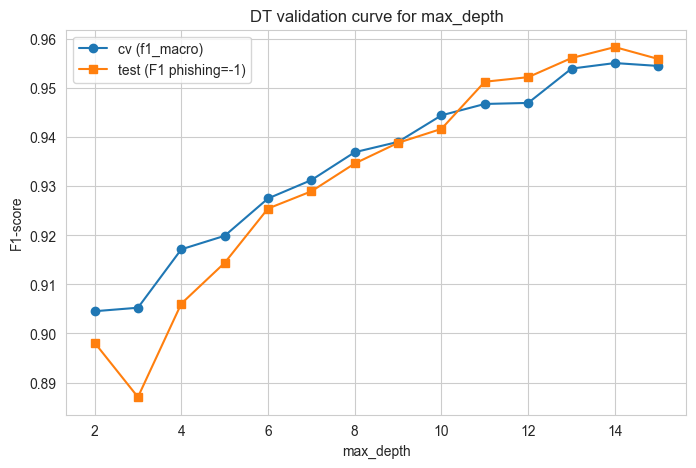

In [27]:
cv_scores_dt, test_scores_dt = [], []
max_depth_values = np.arange(2, 16)

for depth in max_depth_values:
    tree = DecisionTreeClassifier(random_state=random_state, max_depth=depth)
    val_scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='f1_macro')
    cv_scores_dt.append(val_scores.mean())

    tree.fit(X_train, y_train)
    pred_test = tree.predict(X_test)
    test_scores_dt.append(f1_score(y_test, pred_test, pos_label=-1))

plt.plot(max_depth_values, cv_scores_dt, marker='o', label='cv (f1_macro)')
plt.plot(max_depth_values, test_scores_dt, marker='s', label='test (F1 phishing=-1)')
plt.legend()
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('DT validation curve for max_depth')
plt.show()

In [28]:
dict_param_dt = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}
best_tree = grid_search('decision-tree', X_train, y_train, n_jobs=-1, dict_param=dict_param_dt)

best_tree.fit(X_train, y_train)
best_tree_train_f1, best_tree_test_f1 = evaluate(X_train, y_train, X_test, y_test, best_tree)

print('\nTóm tắt kết quả best DT:')
print(f'- Train F1: {best_tree_train_f1:.4f}')
print(f'- Test F1 : {best_tree_test_f1:.4f}')

Best model: DecisionTreeClassifier(max_depth=15, random_state=42)
Best parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1}
Scoring used in GridSearchCV: f1_macro
Đánh giá theo lớp Positive = Phishing (-1)
Train Accuracy: 0.9832654907281773
Train Precision (Phishing=-1): 0.9875840662183135
Train Recall    (Phishing=-1): 0.9744767738642164
Train F1-score  (Phishing=-1): 0.9809866392600206
Train Confusion Matrix:
[[3818  100]
 [  48 4878]]
--------------------------------------------------
Test Accuracy: 0.9615558570782451
Test Precision (Phishing=-1): 0.9725448785638859
Test Recall    (Phishing=-1): 0.939795918367347
Test F1-score  (Phishing=-1): 0.9558899844317592
Test Confusion Matrix:
[[ 921   59]
 [  26 1205]]

Classification report (test):
              precision    recall  f1-score   support

          -1       0.97      0.94      0.96       980
           1       0.95      0.98      0.97      1231

    accuracy                           0.96      2211
   macr

Top 10 feature importances (DT):
01. SSLfinal_State: 0.6344
02. URL_of_Anchor: 0.1148
03. Links_in_tags: 0.0355
04. having_Sub_Domain: 0.0317
05. web_traffic: 0.0263
06. Domain_registeration_length: 0.0179
07. Prefix_Suffix: 0.0177
08. Links_pointing_to_page: 0.0163
09. Request_URL: 0.0106
10. age_of_domain: 0.0098


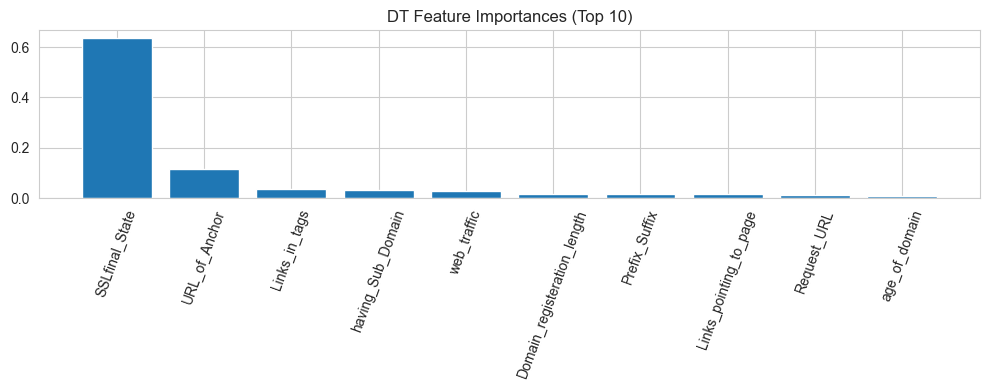

In [18]:
importances_dt = best_tree.feature_importances_
indices_dt = np.argsort(importances_dt)[::-1]

feature_names = X.columns.tolist()
top_k = 10

print('Top 10 feature importances (DT):')
for i in range(top_k):
    idx = indices_dt[i]
    print(f"{i+1:02d}. {feature_names[idx]}: {importances_dt[idx]:.4f}")

plt.figure(figsize=(10, 4))
plt.title('DT Feature Importances (Top 10)')
plt.bar(range(top_k), importances_dt[indices_dt[:top_k]])
plt.xticks(range(top_k), [feature_names[i] for i in indices_dt[:top_k]], rotation=70)
plt.tight_layout()
plt.show()

##### 2.4.2. Random Forest (RF)

##### Khảo sát RF với siêu tham số n_estimators

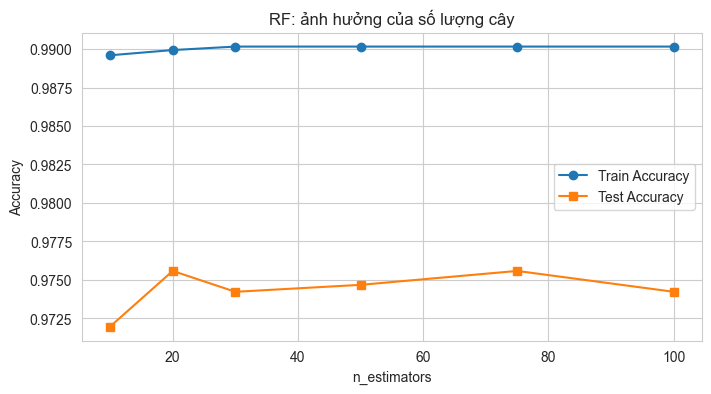

In [19]:
num_trees = [10, 20, 30, 50, 75, 100]
train_acc_rf_curve = []
test_acc_rf_curve = []

for n_tree in num_trees:
    rf_model = RandomForestClassifier(n_estimators=n_tree, random_state=random_state, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    train_acc_rf_curve.append(accuracy_score(y_train, rf_model.predict(X_train)))
    test_acc_rf_curve.append(accuracy_score(y_test, rf_model.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(num_trees, train_acc_rf_curve, marker='o', label='Train Accuracy')
plt.plot(num_trees, test_acc_rf_curve, marker='s', label='Test Accuracy')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('RF: ảnh hưởng của số lượng cây')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
dict_param_rf = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2', None],
    'n_estimators': [50, 100]
}
best_forest = grid_search('random-forest', X_train, y_train, n_jobs=-1, dict_param=dict_param_rf)

best_forest.fit(X_train, y_train)
best_forest_train_f1, best_forest_test_f1 = evaluate(X_train, y_train, X_test, y_test, best_forest)

print('\nTóm tắt kết quả best RF:')
print(f'- Train F1: {best_forest_train_f1:.4f}')
print(f'- Test F1 : {best_forest_test_f1:.4f}')

Best model: RandomForestClassifier(max_depth=15, random_state=42)
Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Scoring used in GridSearchCV: f1_macro
Đánh giá theo lớp Positive = Phishing (-1)
Train Accuracy: 0.9840569877883311
Train Precision (Phishing=-1): 0.9883630721489527
Train Recall    (Phishing=-1): 0.9754977029096478
Train F1-score  (Phishing=-1): 0.9818882466281311
Train Confusion Matrix:
[[3822   96]
 [  45 4881]]
--------------------------------------------------
Test Accuracy: 0.9719583898688376
Test Precision (Phishing=-1): 0.9841772151898734
Test Recall    (Phishing=-1): 0.9520408163265306
Test F1-score  (Phishing=-1): 0.9678423236514524
Test Confusion Matrix:
[[ 933   47]
 [  15 1216]]

Classification report (test):
              precision    recall  f1-score   support

          -1       0.98      0.95      0.97       980
           1       0.96      0.99      0.98      1231

    accuracy                        

Top 10 feature importances (RF):
01. SSLfinal_State: 0.6250
02. URL_of_Anchor: 0.1137
03. Links_in_tags: 0.0328
04. web_traffic: 0.0303
05. having_Sub_Domain: 0.0301
06. Prefix_Suffix: 0.0224
07. Links_pointing_to_page: 0.0187
08. Domain_registeration_length: 0.0128
09. age_of_domain: 0.0119
10. Request_URL: 0.0116


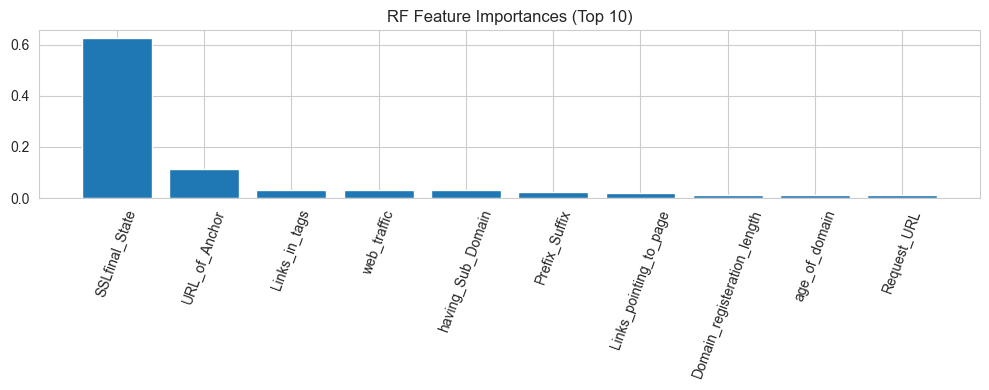

In [21]:
importances_rf = best_forest.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

print('Top 10 feature importances (RF):')
for i in range(10):
    idx = indices_rf[i]
    print(f"{i+1:02d}. {feature_names[idx]}: {importances_rf[idx]:.4f}")

plt.figure(figsize=(10, 4))
plt.title('RF Feature Importances (Top 10)')
plt.bar(range(10), importances_rf[indices_rf[:10]])
plt.xticks(range(10), [feature_names[i] for i in indices_rf[:10]], rotation=70)
plt.tight_layout()
plt.show()

### 3. So sánh nhanh kết quả DT và RF
Kết quả bên dưới tổng hợp F1-score (lớp Phishing = -1) của baseline và mô hình đã tuning.
Ngoài ra, biểu đồ ROC-AUC của best DT và best RF được vẽ trên cùng một hình để so sánh khả năng phân biệt lớp.

Bảng so sánh F1-score cho lớp Phishing (-1):


,Model,F1-score (Phishing=-1)
1,RF Baseline,0.970634
3,RF Best (GridSearch),0.967842
0,DT Baseline,0.967179
2,DT Best (GridSearch),0.955890


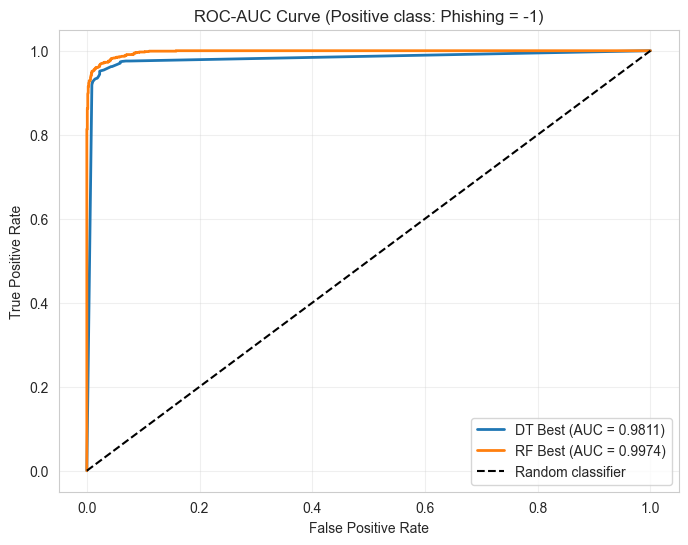

In [30]:
summary = pd.DataFrame({
    'Model': ['DT Baseline', 'RF Baseline', 'DT Best (GridSearch)', 'RF Best (GridSearch)'],
    'F1-score (Phishing=-1)': [f1_dt, f1_rf, best_tree_test_f1, best_forest_test_f1]
}).sort_values('F1-score (Phishing=-1)', ascending=False)

print('Bảng so sánh F1-score cho lớp Phishing (-1):')
display(summary)

# ROC-AUC cho best DT và best RF (xem Phishing=-1 là positive class)
dt_pos_idx = np.where(best_tree.classes_ == -1)[0][0]
rf_pos_idx = np.where(best_forest.classes_ == -1)[0][0]

y_score_dt = best_tree.predict_proba(X_test)[:, dt_pos_idx]
y_score_rf = best_forest.predict_proba(X_test)[:, rf_pos_idx]

y_true_bin = (y_test == -1).astype(int)

fpr_dt, tpr_dt, _ = roc_curve(y_true_bin, y_score_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_true_bin, y_score_rf)

auc_dt = roc_auc_score(y_true_bin, y_score_dt)
auc_rf = roc_auc_score(y_true_bin, y_score_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'DT Best (AUC = {auc_dt:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'RF Best (AUC = {auc_rf:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve (Positive class: Phishing = -1)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()